<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Trial/3_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# copy the vocab.pkl from "/content/gdrive/MyDrive/checkpoints"

# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will use your trained model to generate captions for images in the test dataset.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Get Data Loader for Test Dataset
- [Step 2](#step2): Load Trained Models
- [Step 3](#step3): Finish the Sampler
- [Step 4](#step4): Clean up Captions
- [Step 5](#step5): Generate Predictions!

<a id='step1'></a>
## Step 1: Get Data Loader for Test Dataset

Before running the code cell below, define the transform in `transform_test` that you would like to use to pre-process the test images.  

Make sure that the transform that you define here agrees with the transform that you used to pre-process the training images (in **2_Training.ipynb**).  For instance, if you normalized the training images, you should also apply the same normalization procedure to the test images.

In [2]:
import os
import pickle
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt


In [3]:
import os
if not os.path.exists('data_loader.py'):
    !wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/data_loader.py

--2026-04-17 16:54:08--  https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/data_loader.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7125 (7.0K) [text/plain]
Saving to: ‘data_loader.py’

data_loader.py      100%[===================>]   6.96K  --.-KB/s    in 0s      

2026-04-17 16:54:08 (106 MB/s) - ‘data_loader.py’ saved [7125/7125]



In [4]:
if not os.path.exists('vocabulary.py'):
    !wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/vocabulary.py

--2026-04-17 16:54:08--  https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/vocabulary.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3598 (3.5K) [text/plain]
Saving to: ‘vocabulary.py’

vocabulary.py       100%[===================>]   3.51K  --.-KB/s    in 0s      

2026-04-17 16:54:08 (74.4 MB/s) - ‘vocabulary.py’ saved [3598/3598]



In [5]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [6]:
! mkdir -p models
! cp "/content/gdrive/MyDrive/checkpoints/vocab.pkl" .
! cp "/content/gdrive/MyDrive/checkpoints/attn_coco2014_epoch25.pth" models/

In [7]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils.rnn import pack_padded_sequence
from tqdm import tqdm

import torchvision.transforms as T
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [8]:
cocoapi_loc = Path(".")
coco_root = cocoapi_loc / "cocoapi"
img_root = coco_root / "images"
ann_root = coco_root / "annotations"

(img_root).mkdir(parents=True, exist_ok=True)
(ann_root).mkdir(parents=True, exist_ok=True)

urls = {
    "train2014.zip": "http://images.cocodataset.org/zips/train2014.zip",
    "val2014.zip": "http://images.cocodataset.org/zips/val2014.zip",
    "annotations_trainval2014.zip": "http://images.cocodataset.org/annotations/annotations_trainval2014.zip",
    "image_info_test2014.zip": "http://images.cocodataset.org/annotations/image_info_test2014.zip" # Added for test annotations
}

downloads = coco_root / "downloads"
downloads.mkdir(parents=True, exist_ok=True)

def download_if_missing(url, dst):
    dst = Path(dst)
    if dst.exists():
        print(f"✓ Exists: {dst.name}")
        return
    print(f"Downloading {dst.name} ...")
    urllib.request.urlretrieve(url, dst)
    print(f"Saved -> {dst}")

def unzip_if_missing(zip_path, out_dir, marker_path=None):
    zip_path = Path(zip_path)
    out_dir = Path(out_dir)
    if marker_path is not None and Path(marker_path).exists():
        print(f"✓ Unzip skipped (found): {marker_path}")
        return
    print(f"Unzipping {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    print("Done.")

# 1) Download zips
for fname, url in urls.items():
    download_if_missing(url, downloads / fname)

# 2) Unzip train/val images into ./cocoapi/images/
unzip_if_missing(downloads/"train2014.zip", img_root, marker_path=img_root/"train2014")
unzip_if_missing(downloads/"val2014.zip", img_root, marker_path=img_root/"val2014")

# 3) Unzip annotations into ./cocoapi/annotations/
unzip_if_missing(downloads/"annotations_trainval2014.zip", coco_root, marker_path=ann_root/"captions_train2014.json")
unzip_if_missing(downloads/"image_info_test2014.zip", coco_root, marker_path=ann_root/"image_info_test2014.json") # Added for test annotations

print("\nExpected paths check:")
print("train2014 exists:", (img_root/"train2014").exists())
print("captions_train2014 exists:", (ann_root/"captions_train2014.json").exists())
print("image_info_test2014 exists:", (ann_root/"image_info_test2014.json").exists()) # Added check

Saved -> cocoapi/downloads/train2014.zip
Saved -> cocoapi/downloads/val2014.zip
Saved -> cocoapi/downloads/annotations_trainval2014.zip
Saved -> cocoapi/downloads/image_info_test2014.zip
Unzipping train2014.zip ...
Done.
Unzipping val2014.zip ...
Done.
Unzipping annotations_trainval2014.zip ...
Done.
Unzipping image_info_test2014.zip ...
Done.

Expected paths check:
train2014 exists: True
captions_train2014 exists: True
image_info_test2014 exists: True


In [9]:
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO
from data_loader import get_loader
from torchvision import transforms

# TODO #1: Define a transform to pre-process the testing images.
transform_test = transforms.Compose([
    transforms.Resize(256),                   # Resize image to 256x256
    transforms.CenterCrop(224),               # Crop the center 224x224 portion
    transforms.ToTensor(),                    # Convert to PyTorch Tensor
    transforms.Normalize((0.485, 0.456, 0.406), # Normalize image channels
                         (0.229, 0.224, 0.225))])

#-#-#-# Do NOT modify the code below this line. #-#-#-#

# Create the data loader.
data_loader = get_loader(transform=transform_test,
                         mode='test',
                         cocoapi_loc='.') # Pass the correct location for cocoapi

Vocabulary successfully loaded from vocab.pkl file!


Run the code cell below to visualize an example test image, before pre-processing is applied.

In [10]:
class ImageFolderDataset(Dataset):
    def __init__(self, image_dir, transform=None, extensions=(".jpg", ".jpeg", ".png")):
        self.image_dir = image_dir
        self.transform = transform
        self.paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(extensions)
        ]
        self.paths.sort()
        if len(self.paths) == 0:
            raise RuntimeError(f"No images found in: {image_dir}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, path

In [11]:
!wget http://images.cocodataset.org/zips/val2014.zip

--2026-04-17 17:01:37--  http://images.cocodataset.org/zips/val2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.54.81, 3.5.30.117, 52.216.200.75, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.54.81|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6645013297 (6.2G) [application/zip]
Saving to: ‘val2014.zip’

val2014.zip         100%[===================>]   6.19G  47.5MB/s    in 2m 20s  

2026-04-17 17:03:56 (45.4 MB/s) - ‘val2014.zip’ saved [6645013297/6645013297]



In [12]:
TEST_IMAGE_DEST_DIR = "./test_images"
FINAL_IMAGE_DIR = os.path.join(TEST_IMAGE_DEST_DIR, "val2014")

import os

# Create the destination directory for unzipping
if not os.path.exists(TEST_IMAGE_DEST_DIR):
    os.makedirs(TEST_IMAGE_DEST_DIR)

# Unzip val2014.zip into the destination directory.
# This will create a 'val2014' subdirectory inside TEST_IMAGE_DEST_DIR
# So, the images will be at TEST_IMAGE_DEST_DIR/val2014/
print(f"Unzipping val2014.zip into {TEST_IMAGE_DEST_DIR}...")
!unzip -q val2014.zip -d {TEST_IMAGE_DEST_DIR}
print(f"Unzipped. Images expected in: {FINAL_IMAGE_DIR}")

# Set TEST_IMAGE_DIR to the actual directory containing images
TEST_IMAGE_DIR = FINAL_IMAGE_DIR

test_dataset = ImageFolderDataset(TEST_IMAGE_DIR, transform=transform_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Total test images:", len(test_dataset))
print("Example file:", test_dataset.paths[0])

Unzipping val2014.zip into ./test_images...
Unzipped. Images expected in: ./test_images/val2014
Total test images: 40504
Example file: ./test_images/val2014/COCO_val2014_000000000042.jpg


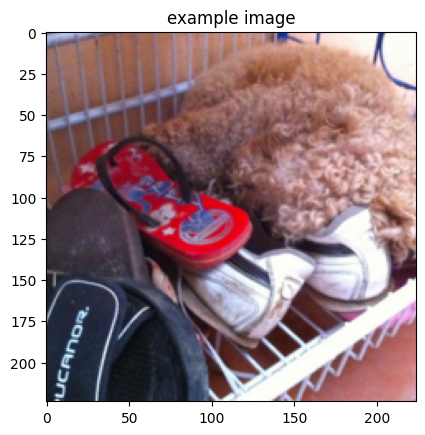

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Obtain sample image before and after pre-processing.
orig_image_batch, _ = next(iter(test_loader))

# Extract a single image from the batch and convert to numpy array,
# then transpose dimensions from (C, H, W) to (H, W, C) for matplotlib.
single_image = orig_image_batch[0].numpy().transpose((1, 2, 0))

# Denormalize the image for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
single_image = std * single_image + mean
single_image = np.clip(single_image, 0, 1)

# Visualize sample image.
plt.imshow(single_image)
plt.title('example image')
plt.show()

<a id='step2'></a>
## Step 2: Load Trained Models

In the next code cell we define a `device` that you will use move PyTorch tensors to GPU (if CUDA is available).  Run this code cell before continuing.

In [14]:
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
import os

# Download model.py if it doesn't exist
if not os.path.exists('model.py'):
    !wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/model.py

from model import EncoderCNN, DecoderRNN

print("model.py has been updated and modules reloaded.")

--2026-04-17 17:04:39--  https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial/model.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13882 (14K) [text/plain]
Saving to: ‘model.py’

model.py            100%[===================>]  13.56K  --.-KB/s    in 0s      

2026-04-17 17:04:39 (168 MB/s) - ‘model.py’ saved [13882/13882]

model.py has been updated and modules reloaded.


Before running the code cell below, complete the following tasks.

### Task #1

In the next code cell, you will load the trained encoder and decoder from the previous notebook (**2_Training.ipynb**).  To accomplish this, you must specify the names of the saved encoder and decoder files in the `models/` folder (e.g., these names should be `encoder-5.pkl` and `decoder-5.pkl`, if you trained the model for 5 epochs and saved the weights after each epoch).  

### Task #2

Plug in both the embedding size and the size of the hidden layer of the decoder corresponding to the selected pickle file in `decoder_file`.

In [16]:
import pickle, torch

with open("vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

checkpoint = torch.load("models/attn_coco2014_epoch25.pth", map_location="cpu")

print("Current vocab size:", len(vocab))
print("Checkpoint vocab size:", checkpoint["decoder_state_dict"]["embedding.weight"].shape[0])


Current vocab size: 8852
Checkpoint vocab size: 8852


In [17]:
import pickle
from vocabulary import Vocabulary

# Load the vocabulary wrapper
with open('vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

print(f"Vocabulary loaded with {len(vocab)} words.")


Vocabulary loaded with 8852 words.


In [18]:
encoder_embed_size = 2048 # Output dimension of EncoderCNN, must match input to attention in DecoderRNN
decoder_embed_size = 512  # Embedding dimension for words in DecoderRNN
hidden_size = 512
num_layers = 1
attention_dim = 512 # Define attention_dim
# Initialize the encoder and decoder
encoder = EncoderCNN(encoded_image_size=7).to(device)  # ✅ FIXED
decoder = DecoderRNN(
    attention_dim=attention_dim,
    embed_size=decoder_embed_size, # Use decoder_embed_size here
    hidden_size=hidden_size,
    vocab_size=len(vocab),
    encoder_dim=2048
).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


In [19]:
#print(decoder.lstm.input_size)

# Define the path to the user's model checkpoint
model_path = 'models/attn_coco2014_epoch25.pth'

# Load the entire checkpoint
checkpoint = torch.load(model_path, map_location=device)

# Load state dicts into the models
encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])

encoder.eval()
decoder.eval()

print(f"Models created and weights loaded from {model_path}.")

Models created and weights loaded from models/attn_coco2014_epoch25.pth.


In [20]:
missing, unexpected = decoder.load_state_dict(
    checkpoint['decoder_state_dict'],
    strict=False
)

print("❌ Missing keys:", missing)
print("❌ Unexpected keys:", unexpected)

❌ Missing keys: []
❌ Unexpected keys: []


In [21]:
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Get a batch of images from the test_loader
batch = next(iter(test_loader))
# Extract the first image from the batch and move it to the device
image_tensor = batch[0][0].to(device)

# Ensure no gradients are computed for inference to save memory
with torch.no_grad():
    features = encoder(image_tensor.unsqueeze(0))

    # Greedy
    caption = decoder.sample(
        features, vocab.word2idx['<start>'], vocab.word2idx['<end>']
    )

    # Beam search
    caption = decoder.beam_search(
        features,
        vocab.word2idx['<start>'],
        vocab.word2idx['<end>'],
        beam_size=5
    )


In [22]:
with torch.no_grad():
    h, c = decoder.init_hidden_state(features)
    context, alpha = decoder.attention(features, h)

    logits = decoder.fc(h)              # first-step logits
    topk = torch.topk(logits, 10, dim=1)

    print("Top-10 tokens at first step:")
    for i in range(10):
        idx = topk.indices[0, i].item()
        print(i, vocab.idx2word[idx], topk.values[0, i].item())

Top-10 tokens at first step:
0 a 6.728672981262207
1 parked 5.781578063964844
2 ready 5.399765491485596
3 pear 5.2606000900268555
4 pavilion 5.176891803741455
5 tusks 5.135631084442139
6 snacks 5.061753749847412
7 bench 5.0485124588012695
8 be 5.005883693695068
9 modified 4.971319198608398


<a id='step3'></a>
## Step 3: Finish the Sampler

Before executing the next code cell, you must write the `sample` method in the `DecoderRNN` class in **model.py**.  This method should accept as input a PyTorch tensor `features` containing the embedded input features corresponding to a single image.

It should return as output a Python list `output`, indicating the predicted sentence.  `output[i]` is a nonnegative integer that identifies the predicted `i`-th token in the sentence.  The correspondence between integers and tokens can be explored by examining either `data_loader.dataset.vocab.word2idx` (or `data_loader.dataset.vocab.idx2word`).

After implementing the `sample` method, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.  Do **not** modify the code in the cell below.

In [23]:

batch = next(iter(test_loader))
print("Type:", type(batch))
print("Length:", len(batch))
for i, item in enumerate(batch):
    print(i, type(item), getattr(item, "shape", None))


Type: <class 'list'>
Length: 2
0 <class 'torch.Tensor'> torch.Size([16, 3, 224, 224])
1 <class 'tuple'> None


In [24]:
# Get a batch of images from the test_loader
batch = next(iter(test_loader))
# Extract the image tensor from the batch and move to device
images = batch[0].to(device)
# Take the first image from the batch and add a batch dimension
image = images[0].unsqueeze(0)

# Obtain the embedded image features.
features = encoder(image)

# Pass the embedded image features through the model to get a predicted caption.
output = decoder.sample(features, vocab.word2idx['<start>'], vocab.word2idx['<end>'])
print('example output:', output)

assert (type(output)==list), "Output needs to be a Python list"
assert all([type(x)==int for x in output]), "Output should be a list of integers."
assert all([x in data_loader.dataset.vocab.idx2word for x in output]), "Each entry in the output needs to correspond to an integer that indicates a token in the vocabulary."

example output: [3, 3, 3, 3, 3, 3, 18]


In [25]:
print("features shape before unsqueeze:", encoder(image).shape)
features = encoder(image).unsqueeze(1)
print("features shape after unsqueeze:", features.shape)

features shape before unsqueeze: torch.Size([1, 49, 2048])
features shape after unsqueeze: torch.Size([1, 1, 49, 2048])


Image path: ./test_images/val2014/COCO_val2014_000000490337.jpg
Caption: a a a a a .


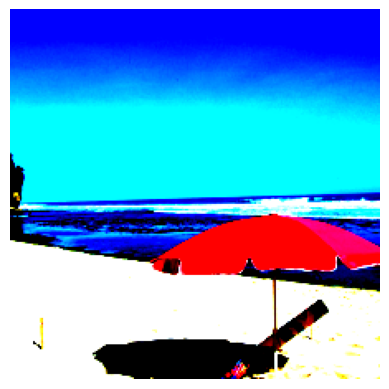

In [26]:
import random

idx = random.randint(0, len(test_dataset) - 1)
image, path = test_dataset[idx]

image = image.to(device)

with torch.no_grad():
    features = encoder(image.unsqueeze(0))
    output_ids = decoder.sample(
        features,
        vocab.word2idx['<start>'],
        vocab.word2idx['<end>']
    )

caption = ' '.join(vocab.idx2word[idx] for idx in output_ids)

print("Image path:", path)
print("Caption:", caption)

plt.imshow(image.permute(1,2,0).cpu())
plt.axis("off")
plt.show()

In [27]:

output_ids = decoder.beam_search(
    features,
    start_idx=vocab.word2idx['<start>'],
    end_idx=vocab.word2idx['<end>'],
    beam_size=5
)

caption = ' '.join(vocab.idx2word[idx] for idx in output_ids)
print(caption)


a a a a a .


<a id='step4'></a>
## Step 4: Clean up the Captions

In the code cell below, complete the `clean_sentence` function.  It should take a list of integers (corresponding to the variable `output` in **Step 3**) as input and return the corresponding predicted sentence (as a single Python string).

In [28]:
def clean_sentence(output_ids):
    # If beam_search returns list WITHOUT <start>/<end>, just join
    words = []
    for idx in output_ids:
        w = vocab.idx2word[idx]
        if w in ['<start>', '<pad>']:
            continue
        if w == '<end>':
            break
        words.append(w)
    return " ".join(words)

After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

In [29]:
sentence = clean_sentence(output)
print('example sentence:', sentence)

assert type(sentence)==str, 'Sentence needs to be a Python string!'

example sentence: a a a a a a .


<a id='step5'></a>
## Step 5: Generate Predictions!

In the code cell below, we have written a function (`get_prediction`) that you can use to use to loop over images in the test dataset and print your model's predicted caption.

In [30]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

def get_prediction(beam_size=5):
    """
    Generate a caption for a randomly selected test image using BEAM SEARCH.
    """

    encoder.eval()
    decoder.eval()

    # Randomly select an image from the test dataset
    idx = random.randint(0, len(test_dataset) - 1)
    image, path = test_dataset[idx]

    # Move image to device and add batch dimension
    image_for_encoder = image.unsqueeze(0).to(device)

    with torch.no_grad():
        # Encode image
        features = encoder(image_for_encoder)

        # ✅ Use BEAM SEARCH instead of greedy decoding
        output_ids = decoder.beam_search(
            features,
            start_idx=vocab.word2idx['<start>'],
            end_idx=vocab.word2idx['<end>'],
            beam_size=beam_size
        )

    # Convert token IDs to readable sentence
    sentence = clean_sentence(output_ids)

    # ----- Prepare image for display -----
    display_image = image.permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    display_image = std * display_image + mean
    display_image = np.clip(display_image, 0, 1)

    # Print results
    print(f"Image path: {path}")
    print(f"Predicted caption (beam_size={beam_size}): {sentence}")

    # Show image
    plt.imshow(display_image)
    plt.title("Sample Image")
    plt.axis("off")
    plt.show()

Run the code cell below (multiple times, if you like!) to test how this function works.

Image path: ./test_images/val2014/COCO_val2014_000000435475.jpg
Predicted caption (beam_size=5): a a a a .


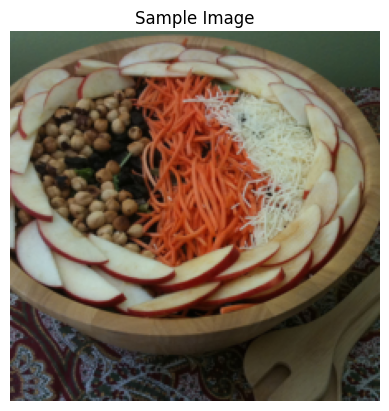

In [31]:
get_prediction()

As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

Image path: ./test_images/val2014/COCO_val2014_000000265050.jpg
Predicted caption (beam_size=5): a a a a a a


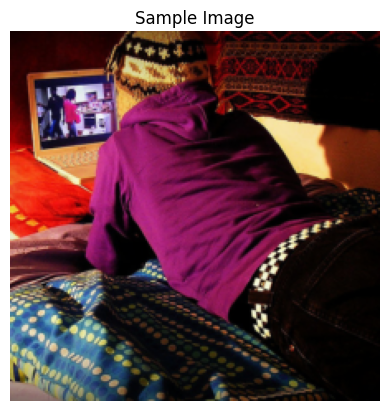

In [32]:
get_prediction()

Image path: ./test_images/val2014/COCO_val2014_000000279864.jpg
Predicted caption (beam_size=5): a a a a a .


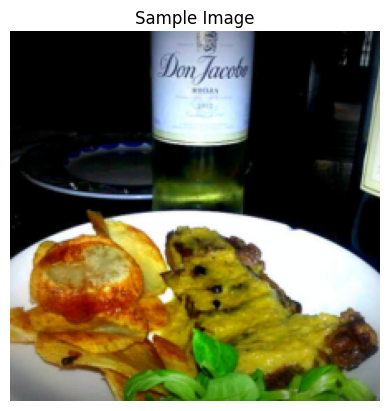

In [33]:
get_prediction()

### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.

Image path: ./test_images/val2014/COCO_val2014_000000286524.jpg
Predicted caption (beam_size=5): a a a a a .


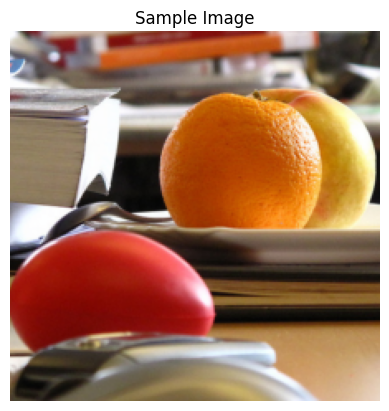

In [34]:
get_prediction()

Image path: ./test_images/val2014/COCO_val2014_000000020059.jpg
Predicted caption (beam_size=5): a a a a a a .


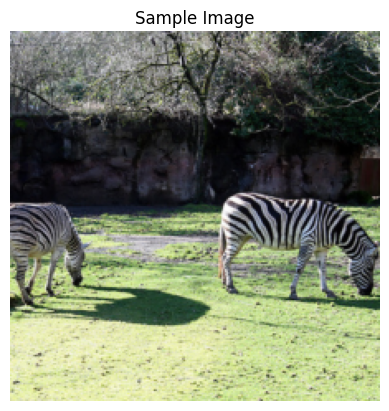

In [35]:
get_prediction()

In [37]:
print(f"Token ID 3 maps to: {vocab.idx2word[3]}")


Token ID 3 maps to: a


In [38]:

import model, inspect
from model import DecoderRNN

print("model.py used from:", model.__file__)
print("\nbeam_search signature:\n", inspect.signature(DecoderRNN.beam_search))
print("\nbeam_search first 20 lines:\n")
print("\n".join(inspect.getsource(DecoderRNN.beam_search).splitlines()[:20]))


model.py used from: /content/model.py

beam_search signature:
 (self, encoder_out: 'torch.Tensor', start_idx: 'int', end_idx: 'int', beam_size: 'int' = 5, max_len: 'int' = 20, length_norm_alpha: 'float' = 0.7)

beam_search first 20 lines:

    @torch.no_grad()
    def beam_search(
        self,
        encoder_out: torch.Tensor,
        start_idx: int,
        end_idx: int,
        beam_size: int = 5,
        max_len: int = 20,
        length_norm_alpha: float = 0.7,
    ):
        """
        Correct beam search caption generation.

        Assumes:
            encoder_out: (1, num_pixels, encoder_dim)

        Returns:
            best_seq: list of token ids (without <start>/<end>)
        """
        device = encoder_out.device


In [39]:
print("Beam output ids:", output_ids)
print("Words:", [vocab.idx2word[i] for i in output_ids])

Beam output ids: [3, 3, 3, 3, 3, 18]
Words: ['a', 'a', 'a', 'a', 'a', '.']


If token ID 3 maps to a generic word (like 'a' or '<unk>'), the problem likely lies in how the `DecoderRNN.sample()` and `DecoderRNN.beam_search()` methods are implemented in your `model.py` file. These methods are responsible for selecting the next word in the sequence.

Here are some steps to debug them:

1.  **Examine `DecoderRNN.sample()` and `DecoderRNN.beam_search()`:** Check the logic in `model.py` for both of these methods. Ensure that the recurrent neural network (LSTM) is correctly processing inputs and producing varied outputs.
    *   **Input Embedding:** Verify that the previous word's embedding is correctly fed into the LSTM.
    *   **Attention Mechanism:** If you are using attention, ensure the attention weights are dynamic and the context vector changes based on the image features for each decoding step.
    *   **LSTM State Updates:** Confirm that the hidden and cell states of the LSTM are being updated correctly in each time step.
    *   **Logit Generation and `argmax`:** Make sure the linear layer outputs diverse logits, and that the `argmax` operation (or beam search logic) is genuinely selecting the most probable next token, and not getting stuck on a single high-probability token.

2.  **Check for Constant Inputs:** Sometimes, if the embedded input to the decoder remains constant or nearly constant, the decoder will produce repetitive outputs.

3.  **Review Initialization:** Double-check that the `EncoderCNN` and `DecoderRNN` are initialized with appropriate dimensions and that their weights are correctly loaded.

Since I cannot directly modify `model.py`, please inspect these methods in your `model.py` file based on these suggestions. If you find a specific part that seems problematic, you can paste it here for further assistance.